In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(
        degrees=15,              # rotate ±15°
        shear=0.1,              # shear up to 10%
        translate=(0.1, 0.1),    # shift up to 10% in x/y
        scale=(0.9, 1.1),        # zoom in/out
    ),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="data/output",
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=True
)

print("Loaded ", len(dataset.classes), " classes")

Loaded  386  classes


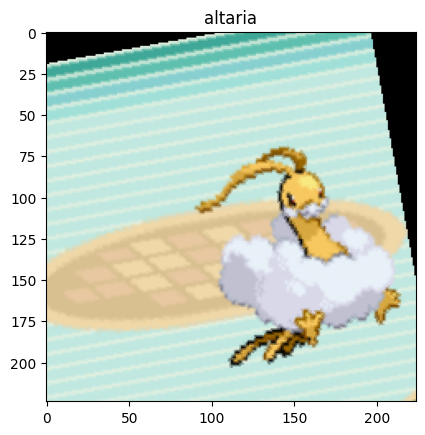

In [66]:
import matplotlib.pyplot as plt

img, label = dataset[800]
plt.imshow(img.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 386  # change this to your real number

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)


In [67]:
num_classes = len(dataset.classes)
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [ ]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')

print("Start Model Train")
for epoch in range(100):
    print("Starting epoch " + str(epoch))
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch}: Val Loss = {val_loss:.4f}")

    # ---- Save best model ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "RESbest_model.pth")
        print("Saved new best model!")

Start Model Train
Starting epoch 0
